# 4. Runde mit nur noch 5 Modellen
Für die Modellierung werden vier verschiedene Machine-Learning-Algorithmen getestet: RandomForestClassifier, GradientBoostingClassifier (sklearn), LGBMClassifier (LightGBM) und CatBoostClassifier. Für jedes Modell wird eine Hyperparameter-Optimierung durchgeführt, indem 50 zufällige Parameterkombinationen ausgetestet werden. Hierbei werden sowohl Randomized Search als auch Grid Search zum Einsatz kommen, abhängig von Modellkomplexität und Parameterraum. Zur Bewertung der Modelle wird eine 5-fache Cross-Validation verwendet werden, um robuste und verlässliche Ergebnisse zu erzielen. Als Bewertungsgröße wird durchgängig die angepasste Custom Loss Function dienen, um die Modelle möglichst nah an den späteren Praxiseinsatzbedingungen auszurichten.

Da alle getesteten Modelle standardmäßig mit einem Schwellenwert von 0.5 für die Klassenzuordnung arbeiten, wird zusätzlich eine nachgelagerte Threshold-Optimierung durchgeführt. Ziel dieser Optimierung wird es sein, den Threshold so anzupassen, dass die betroffenen Fehlklassifikationskosten weiter minimiert werden. Hierfür werden systematisch Thresholds im Bereich von 0.1 bis 0.9 durchlaufen und jeweils der Custom Loss auf den Testdaten neu berechnet werden.

- XGBClassifier **--> (macht David und erfolgt daher nicht in diesem Notebook)**


## Hyperparameter-Optimierung mit 50 Iterationen

In [ ]:
# Standard Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import logging
import inspect

# sklearn
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay, 
    roc_auc_score, RocCurveDisplay, precision_recall_curve, PrecisionRecallDisplay
)
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier

# neue Modelle (nach pip install)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from imblearn.ensemble import BalancedRandomForestClassifier, RUSBoostClassifier

# Logging & Warnings Setup
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
warnings.filterwarnings("ignore")

In [2]:
# Preprocessor laden
from pipeline.data_pipeline import preprocessor, X, y

## 1. Datenaufteilung

In [3]:

# damage extrahieren und aus X entfernen
damage_series = X['damage'].copy()
X = X.drop(columns=['damage'])

# stratify=y sorgt für eine proportionale Aufteilung der Klassen in Train/Test, wichtig bei unbalancierten Datensets.
if isinstance(y, pd.Series) and y.nunique() > 1 and y.notnull().all():
    stratify_param = y
else:
    stratify_param = None

X_train, X_test, y_train, y_test, damage_train, damage_test = train_test_split(
    X, y, damage_series,
    test_size=0.2,
    random_state=42,
    stratify=stratify_param
)


In [4]:
X

,id,store_id,cash_desk,transaction_start,transaction_end,total_amount,n_lines,payment_medium,customer_feedback,opening_date,location,state,urbanization,sco_introduction,transaction_lines_details
2,b642f9b6-43b5-413d-ad08-b4bf4b664b52,b0973ffa-ce15-41e0-9de7-1390598e24f2,2,2022-02-02 08:07:12.000000,2022-02-02 08:11:29.434607,363.87,37,CREDIT_CARD,NaN,2005-06-02,Berlin,Berlin,RURAL,2022-02-02,"[{'age_restricted': False, 'base_product_id': ..."
5,fc8400da-2ac2-4984-bb8f-a6ea29df955a,b0973ffa-ce15-41e0-9de7-1390598e24f2,1,2022-02-02 08:21:12.000000,2022-02-02 08:21:48.404849,75.58,3,CREDIT_CARD,NaN,2005-06-02,Berlin,Berlin,RURAL,2022-02-02,"[{'age_restricted': False, 'base_product_id': ..."
9,3d7dbe6e-2a67-4a4d-8011-394b44774c53,b0973ffa-ce15-41e0-9de7-1390598e24f2,1,2022-02-02 08:48:09.000000,2022-02-02 08:51:20.530141,218.51,23,CREDIT_CARD,NaN,2005-06-02,Berlin,Berlin,RURAL,2022-02-02,"[{'age_restricted': False, 'base_product_id': ..."
17,d54e5513-bdbe-4129-bafc-dc4a15747260,b0973ffa-ce15-41e0-9de7-1390598e24f2,1,2022-02-02 09:11:15.000000,2022-02-02 09:14:02.177041,323.95,27,CREDIT_CARD,NaN,2005-06-02,Berlin,Berlin,RURAL,2022-02-02,"[{'age_restricted': False, 'base_product_id': ..."
32,6e1a71c4-b210-427e-8882-5385f9b9253e,b0973ffa-ce15-41e0-9de7-1390598e24f2,3,2022-02-02 10:04:06.000000,2022-02-02 10:04:27.311571,58.87,4,CREDIT_CARD,NaN,2005-06-02,Berlin,Berlin,RURAL,2022-02-02,"[{'age_restricted': False, 'base_product_id': ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1558167,93e0f4b3-810a-46c7-837e-7b84b2a4c673,ed996b17-17d6-47e8-9262-d1d02b52cdb4,0,2023-12-30 21:12:15.000000,2023-12-30 21:13:17.665744,47.28,8,CREDIT_CARD,NaN,1994-09-19,München,Bayern,TOWNS,2022-02-06,"[{'age_restricted': False, 'base_product_id': ..."
1558170,81d32eb7-7b5d-48e5-9c25-18a0148ba907,ed996b17-17d6-47e8-9262-d1d02b52cdb4,2,2023-12-30 21:13:18.000000,2023-12-30 21:16:37.092689,264.25,22,CREDIT_CARD,10.0,1994-09-19,München,Bayern,TOWNS,2022-02-06,"[{'age_restricted': False, 'base_product_id': ..."
1558173,14ce6f9e-64a9-4c93-b834-cde34d80704d,ed996b17-17d6-47e8-9262-d1d02b52cdb4,1,2023-12-30 21:14:42.000000,2023-12-30 21:19:28.465321,297.95,38,CREDIT_CARD,NaN,1994-09-19,München,Bayern,TOWNS,2022-02-06,"[{'age_restricted': False, 'base_product_id': ..."
1558175,c63b715f-4b23-485a-92e9-7bca82775d4c,ed996b17-17d6-47e8-9262-d1d02b52cdb4,2,2023-12-30 21:16:41.074339,2023-12-30 21:19:32.503266,398.57,27,CREDIT_CARD,NaN,1994-09-19,München,Bayern,TOWNS,2022-02-06,"[{'age_restricted': False, 'base_product_id': ..."


## 2. Zielfunktion definieren

In [5]:
def custom_objective_score(y_true, y_pred, damage_series):
    """
    Custom Zielfunktion:
    Score = -Summe Schaden der FN + (5 * TP) - (10 * FP)
    """
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP, FN, TP = cm.ravel()
    
    fn_mask = (y_true == 1) & (y_pred == 0)
    sum_damage_fn = damage_series[fn_mask].sum()
    
    score = -sum_damage_fn + (5 * TP) - (10 * FP)
    return float(score)

## 3. Evaluationsfunktion definieren

In [6]:
def evaluate_model_with_curves(model, model_name, preprocessor, X_train, X_test, y_train, y_test, damage_test, threshold):
    logging.info(f"🔍 Starte Evaluation für Modell: {model_name}")

    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    if y_train.isnull().any():
        logging.warning(f"y_train enthält NaN-Werte: {y_train.isnull().sum()} fehlende Werte!")
        return

    try:
        pipeline.fit(X_train, y_train)
    except Exception as e:
        logging.exception(f"Fehler beim Training: {e}")
        return

    has_proba = hasattr(model, "predict_proba")
    if has_proba:
        y_scores = pipeline.predict_proba(X_test)[:, 1]
        y_pred = (y_scores >= threshold).astype(int)
    else:
        logging.warning("⚠️ Modell unterstützt kein predict_proba.")
        y_scores = None
        y_pred = pipeline.predict(X_test)

    # Klassifikationsbericht
    print("\n📋 Klassifikationsbericht:")
    print(classification_report(y_test, y_pred, target_names=["NORMAL", "FRAUD"]))

    # Konfusionsmatrix
    cm = confusion_matrix(y_test, y_pred)
    print("\n🔲 Konfusionsmatrix:")
    print(cm)
    ConfusionMatrixDisplay(cm, display_labels=["NORMAL", "FRAUD"]).plot(cmap="Blues")
    plt.title(f"Konfusionsmatrix – {model_name} (Threshold: {threshold:.2f})")
    plt.show()

    # ROC & PR-Kurven
    if has_proba and y_scores is not None:
        auc = roc_auc_score(y_test, y_scores)
        logging.info(f"📈 ROC-AUC: {auc:.4f}")
        RocCurveDisplay.from_predictions(y_test, y_scores).plot()
        plt.plot([0, 1], [0, 1], 'k--', label='Zufall')
        plt.legend()
        plt.title(f"ROC-Kurve – {model_name}")
        plt.show()

        precision, recall, _ = precision_recall_curve(y_test, y_scores)
        PrecisionRecallDisplay(precision=precision, recall=recall).plot()
        plt.title(f"Precision-Recall-Kurve – {model_name}")
        plt.show()

    if len(y_test) != len(damage_test):
        logging.error("Länge von y_test und damage_test stimmen nicht überein!")
        return

    custom_score = custom_objective_score(y_test.reset_index(drop=True), y_pred, damage_test.reset_index(drop=True))
    print(f"\n🎯 Wert der Zielfunktion: {custom_score:.2f}")

    return custom_score  # Optionaler Rückgabewert

## 4. Randomized Search mit Custom Scoring

In [ ]:
def randomized_search_with_custom_score(model_class, param_grid, preprocessor, 
                                        X, y, damage_series, 
                                        model_fixed_params=None, 
                                        n_iter=10, cv_splits=5, random_state=42):
    """
    Randomisierte Hyperparameter-Suche mit Custom Objective Function und optionalen festen Modellparametern.
    """
    # Sicherstellen, dass random_state immer gesetzt wird
    if model_fixed_params is None:
        model_fixed_params = {}

    if 'random_state' in inspect.signature(model_class).parameters and 'random_state' not in model_fixed_params:
        model_fixed_params['random_state'] = random_state

    rng = np.random.default_rng(seed=random_state)
    skf = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=random_state)
    best_score = -np.inf
    best_params = None
    param_grid_items = list(param_grid.items())

    for iteration in range(n_iter):
        params = {key: rng.choice(list(values)) for key, values in param_grid_items}
        full_params = {**params}
        if model_fixed_params:
            full_params.update(model_fixed_params)

        logging.info(f"\n➡️ Iteration {iteration+1}: teste Parameter {full_params}")
        fold_scores = []

        for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y), 1):
            X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
            y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]
            damage_valid = damage_series.iloc[valid_idx]

            pipeline = Pipeline([
                ('preprocessor', preprocessor),
                ('classifier', model_class(**full_params))
            ])

            try:
                pipeline.fit(X_train, y_train)
                y_pred = pipeline.predict(X_valid)
                score = custom_objective_score(
                    y_valid.reset_index(drop=True),
                    y_pred,
                    damage_valid.reset_index(drop=True)
                )
                fold_scores.append(score)
                logging.info(f"  Fold {fold} Score: {score:.2f}")
            except Exception as e:
                logging.error(f"❌ Fehler in Fold {fold}: {e}")
                continue

        if not fold_scores:
            logging.warning(f"⚠️ Keine gültigen Folds in Iteration {iteration+1}.")
            continue

        mean_score = np.mean(fold_scores)
        logging.info(f"  ➡️ Durchschnittlicher CV-Score: {mean_score:.2f}")

        if mean_score > best_score:
            best_score = mean_score
            best_params = full_params

    logging.info("\n✅ Beste Parameter gefunden!")
    logging.info(f"✅ Parameter: {best_params}")
    logging.info(f"✅ CV-Score: {best_score:.2f}")
    return best_params, best_score

## 5. Hyperparameter-Setup mit allen Modellen
Die bisherigen optimalen Parameter liefern schon eine klare Tendenz. Komplett breiter Zufalls-Suchraum wäre jetzt nur noch Zeitverschwendung. Jetzt wollen wir daher fokussierter suchen.

In [8]:
model_configs = [
    {
        'name': 'RandomForestClassifier',
        'model_class': RandomForestClassifier,
        'param_grid': {
            'n_estimators': [400, 500, 600],
            'max_depth': [10, 20, 30], 
            'min_samples_split': [5, 10]
        },
        'fixed_params': {'n_jobs': 4}
    },
    {
        'name': 'GradientBoostingClassifier',
        'model_class': GradientBoostingClassifier,
        'param_grid': {
            'n_estimators': [200, 300, 400],
            'learning_rate': [0.03, 0.05, 0.07],
            'max_depth': [2, 3, 4],
            'subsample': [0.8, 1.0]    
        },
        'fixed_params': {}
    },
    {
        'name': 'CatBoostClassifier',
        'model_class': CatBoostClassifier,
        'param_grid': {
            'iterations': [100, 200, 300],
            'learning_rate': [0.08, 0.1],
            'depth': [4, 6, 8]
        },
        'fixed_params': {'verbose': 0}
    },
    {
        'name': 'LGBMClassifier',
        'model_class': LGBMClassifier,
        'param_grid': {
            'n_estimators': [100, 200, 300],
            'learning_rate': [0.03, 0.05, 0.07],
            'num_leaves': [40, 50, 60],
            'max_depth': [4, 5, 6]         
        },
        'fixed_params': {'n_jobs': 4}
    },
    
] 

## 6. Ausgabe aller Ergebnisse

2025-06-08 22:24:33,106 - INFO - 
➡️ Iteration 1: teste Parameter {'n_estimators': 400, 'max_depth': 30, 'min_samples_split': 10, 'n_jobs': 4}




🔍 Tune: RandomForestClassifier


2025-06-08 22:25:23,409 - INFO -   Fold 1 Score: -6570.68
2025-06-08 22:25:56,983 - INFO -   Fold 2 Score: -5909.15
2025-06-08 22:26:30,536 - INFO -   Fold 3 Score: -6244.05
2025-06-08 22:27:02,469 - INFO -   Fold 4 Score: -6109.49
2025-06-08 22:27:02,469 - INFO -   ➡️ Durchschnittlicher CV-Score: -6208.34
2025-06-08 22:27:02,469 - INFO - 
➡️ Iteration 2: teste Parameter {'n_estimators': 500, 'max_depth': 20, 'min_samples_split': 10, 'n_jobs': 4}
2025-06-08 22:27:40,237 - INFO -   Fold 1 Score: -6530.74
2025-06-08 22:28:19,575 - INFO -   Fold 2 Score: -5881.34
2025-06-08 22:29:13,351 - INFO -   Fold 3 Score: -6240.50
2025-06-08 22:30:16,111 - INFO -   Fold 4 Score: -5999.27
2025-06-08 22:30:16,111 - INFO -   ➡️ Durchschnittlicher CV-Score: -6162.96
2025-06-08 22:30:16,126 - INFO - 
➡️ Iteration 3: teste Parameter {'n_estimators': 400, 'max_depth': 30, 'min_samples_split': 5, 'n_jobs': 4}
2025-06-08 22:31:07,674 - INFO -   Fold 1 Score: -6576.68
2025-06-08 22:32:00,054 - INFO -   Fold 2


📋 Klassifikationsbericht:
              precision    recall  f1-score   support

      NORMAL       0.97      1.00      0.99     30139
       FRAUD       0.71      0.17      0.28      1000

    accuracy                           0.97     31139
   macro avg       0.84      0.58      0.63     31139
weighted avg       0.96      0.97      0.96     31139


🔲 Konfusionsmatrix:
[[30068    71]
 [  829   171]]


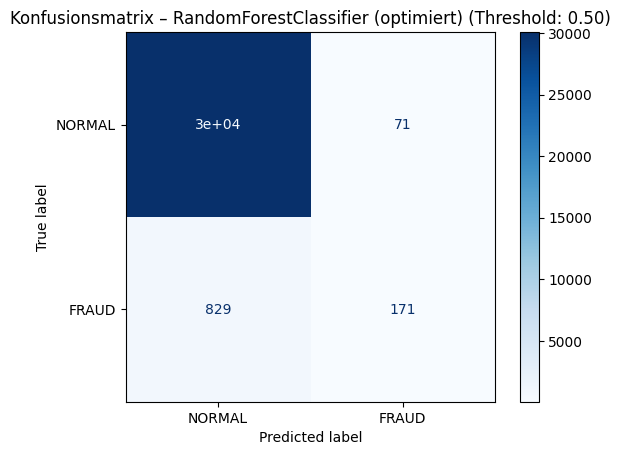

2025-06-09 00:19:49,450 - INFO - 📈 ROC-AUC: 0.8188


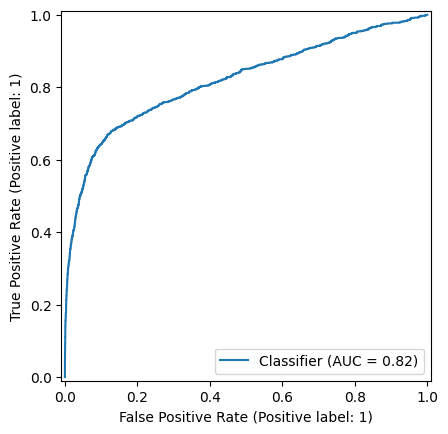

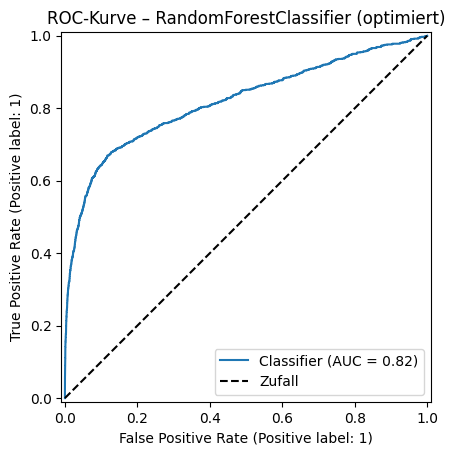

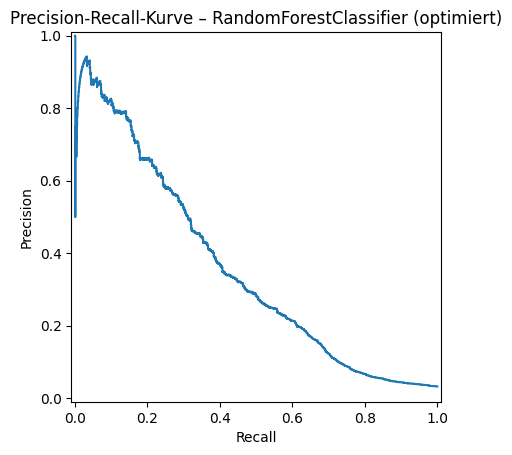

2025-06-09 00:19:49,860 - INFO - 
➡️ Iteration 1: teste Parameter {'n_estimators': 200, 'learning_rate': 0.07, 'max_depth': 3, 'subsample': 0.8}



🎯 Wert der Zielfunktion: -6084.04


🔍 Tune: GradientBoostingClassifier


2025-06-09 00:20:49,635 - INFO -   Fold 1 Score: -6794.47
2025-06-09 00:21:48,483 - INFO -   Fold 2 Score: -5845.69
2025-06-09 00:22:46,983 - INFO -   Fold 3 Score: -6257.18
2025-06-09 00:23:45,996 - INFO -   Fold 4 Score: -6021.56
2025-06-09 00:23:45,997 - INFO -   ➡️ Durchschnittlicher CV-Score: -6229.73
2025-06-09 00:23:45,998 - INFO - 
➡️ Iteration 2: teste Parameter {'n_estimators': 300, 'learning_rate': 0.07, 'max_depth': 2, 'subsample': 1.0}
2025-06-09 00:24:58,353 - INFO -   Fold 1 Score: -6666.08
2025-06-09 00:26:10,403 - INFO -   Fold 2 Score: -5735.92
2025-06-09 00:27:21,971 - INFO -   Fold 3 Score: -6248.59
2025-06-09 00:28:33,475 - INFO -   Fold 4 Score: -5951.93
2025-06-09 00:28:33,476 - INFO -   ➡️ Durchschnittlicher CV-Score: -6150.63
2025-06-09 00:28:33,477 - INFO - 
➡️ Iteration 3: teste Parameter {'n_estimators': 200, 'learning_rate': 0.03, 'max_depth': 3, 'subsample': 1.0}
2025-06-09 00:29:43,345 - INFO -   Fold 1 Score: -6714.45
2025-06-09 00:30:54,159 - INFO -   F


📋 Klassifikationsbericht:
              precision    recall  f1-score   support

      NORMAL       0.97      1.00      0.99     30139
       FRAUD       0.70      0.18      0.28      1000

    accuracy                           0.97     31139
   macro avg       0.84      0.59      0.63     31139
weighted avg       0.96      0.97      0.96     31139


🔲 Konfusionsmatrix:
[[30065    74]
 [  824   176]]


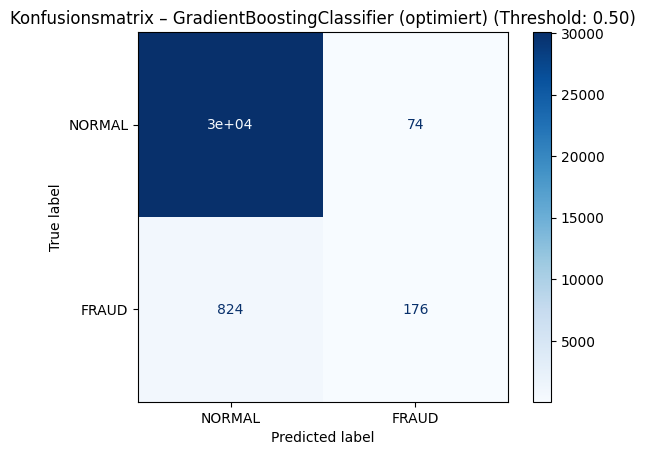

2025-06-09 05:57:21,741 - INFO - 📈 ROC-AUC: 0.8409


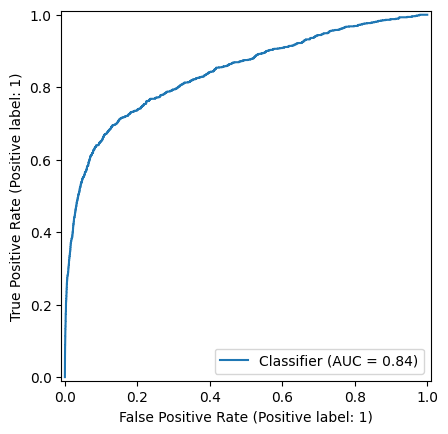

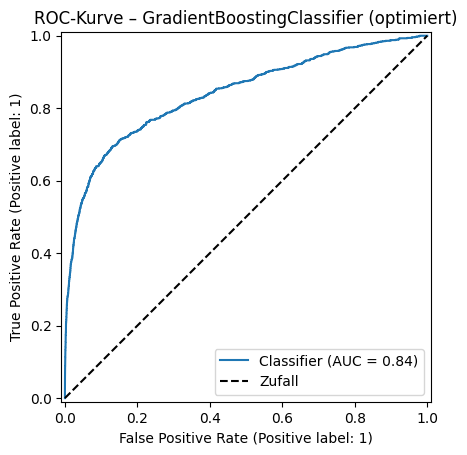

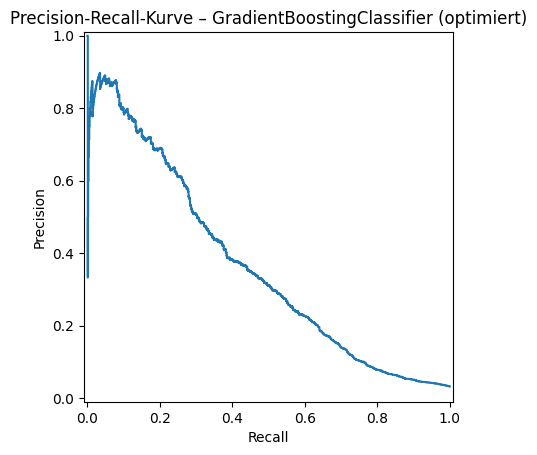

2025-06-09 05:57:22,156 - INFO - 
➡️ Iteration 1: teste Parameter {'iterations': 100, 'learning_rate': 0.1, 'depth': 6, 'verbose': 0}



🎯 Wert der Zielfunktion: -6038.90


🔍 Tune: CatBoostClassifier


2025-06-09 05:57:29,190 - INFO -   Fold 1 Score: -6603.76
2025-06-09 05:57:35,934 - INFO -   Fold 2 Score: -5770.70
2025-06-09 05:57:42,749 - INFO -   Fold 3 Score: -6167.55
2025-06-09 05:57:49,512 - INFO -   Fold 4 Score: -5922.36
2025-06-09 05:57:49,513 - INFO -   ➡️ Durchschnittlicher CV-Score: -6116.09
2025-06-09 05:57:49,515 - INFO - 
➡️ Iteration 2: teste Parameter {'iterations': 200, 'learning_rate': 0.08, 'depth': 8, 'verbose': 0}
2025-06-09 05:57:58,980 - INFO -   Fold 1 Score: -6637.47
2025-06-09 05:58:08,522 - INFO -   Fold 2 Score: -5939.64
2025-06-09 05:58:17,998 - INFO -   Fold 3 Score: -6138.67
2025-06-09 05:58:27,617 - INFO -   Fold 4 Score: -6098.10
2025-06-09 05:58:27,618 - INFO -   ➡️ Durchschnittlicher CV-Score: -6203.47
2025-06-09 05:58:27,618 - INFO - 
➡️ Iteration 3: teste Parameter {'iterations': 100, 'learning_rate': 0.1, 'depth': 4, 'verbose': 0}
2025-06-09 05:58:34,282 - INFO -   Fold 1 Score: -6668.90
2025-06-09 05:58:40,984 - INFO -   Fold 2 Score: -5715.41


📋 Klassifikationsbericht:
              precision    recall  f1-score   support

      NORMAL       0.97      1.00      0.99     30139
       FRAUD       0.73      0.19      0.30      1000

    accuracy                           0.97     31139
   macro avg       0.85      0.59      0.64     31139
weighted avg       0.97      0.97      0.96     31139


🔲 Konfusionsmatrix:
[[30069    70]
 [  811   189]]


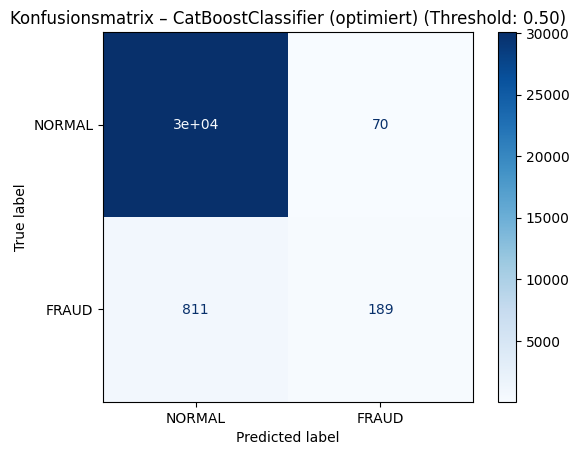

2025-06-09 06:26:09,532 - INFO - 📈 ROC-AUC: 0.8395


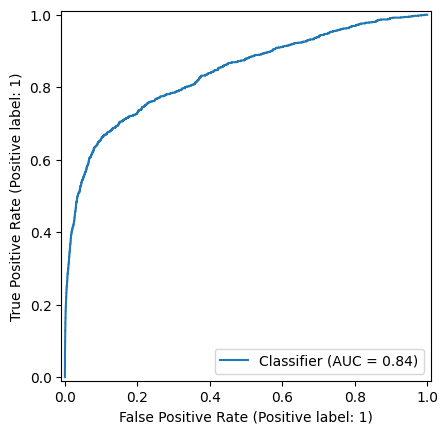

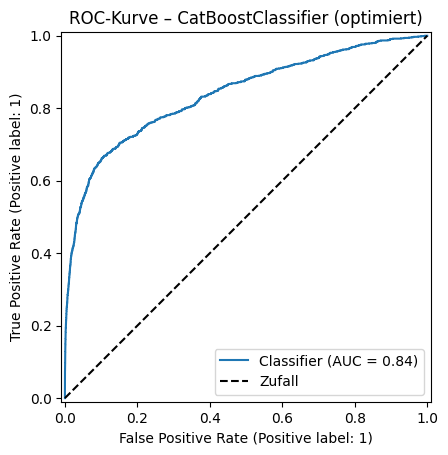

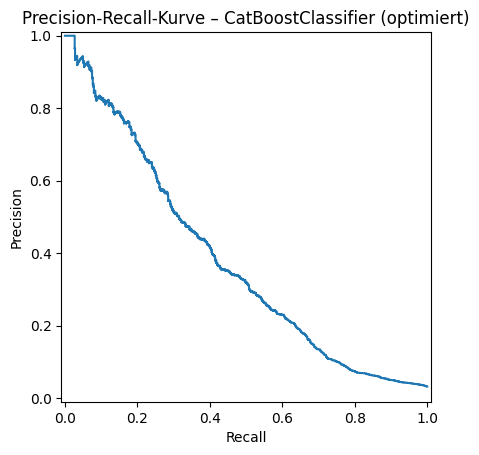

2025-06-09 06:26:09,922 - INFO - 
➡️ Iteration 1: teste Parameter {'n_estimators': 100, 'learning_rate': 0.07, 'num_leaves': 50, 'max_depth': 5, 'n_jobs': 4}



🎯 Wert der Zielfunktion: -5875.64


🔍 Tune: LGBMClassifier
[LightGBM] [Info] Number of positive: 3000, number of negative: 90414
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010455 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2191
[LightGBM] [Info] Number of data points in the train set: 93414, number of used features: 38
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.032115 -> initscore=-3.405787
[LightGBM] [Info] Start training from score -3.405787
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

2025-06-09 06:26:14,856 - INFO -   Fold 1 Score: -6678.89


[LightGBM] [Info] Number of positive: 3000, number of negative: 90415
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011921 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2197
[LightGBM] [Info] Number of data points in the train set: 93415, number of used features: 38
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.032115 -> initscore=-3.405798
[LightGBM] [Info] Start training from score -3.405798
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

2025-06-09 06:26:19,761 - INFO -   Fold 2 Score: -5961.80


...

[LightGBM] [Info] Number of positive: 3000, number of negative: 90415
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.012012 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2196
[LightGBM] [Info] Number of data points in the train set: 93415, number of used features: 38
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.032115 -> initscore=-3.405798
[LightGBM] [Info] Start training from score -3.405798
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

2025-06-09 06:44:05,527 - INFO -   Fold 4 Score: -6069.56
2025-06-09 06:44:05,528 - INFO -   ➡️ Durchschnittlicher CV-Score: -6212.38
2025-06-09 06:44:05,532 - INFO - 
✅ Beste Parameter gefunden!
2025-06-09 06:44:05,554 - INFO - ✅ Parameter: {'n_estimators': 300, 'learning_rate': 0.07, 'num_leaves': 60, 'max_depth': 4, 'n_jobs': 4}
2025-06-09 06:44:05,556 - INFO - ✅ CV-Score: -6142.82


[LightGBM] [Info] Number of positive: 4000, number of negative: 120553
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.015723 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2203
[LightGBM] [Info] Number of data points in the train set: 124553, number of used features: 38
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.032115 -> initscore=-3.405795
[LightGBM] [Info] Start training from score -3.405795
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive ga

2025-06-09 06:44:11,383 - INFO - 🔍 Starte Evaluation für Modell: LGBMClassifier (optimiert)


[LightGBM] [Info] Number of positive: 4000, number of negative: 120553
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010679 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2203
[LightGBM] [Info] Number of data points in the train set: 124553, number of used features: 38
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.032115 -> initscore=-3.405795
[LightGBM] [Info] Start training from score -3.405795
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive ga

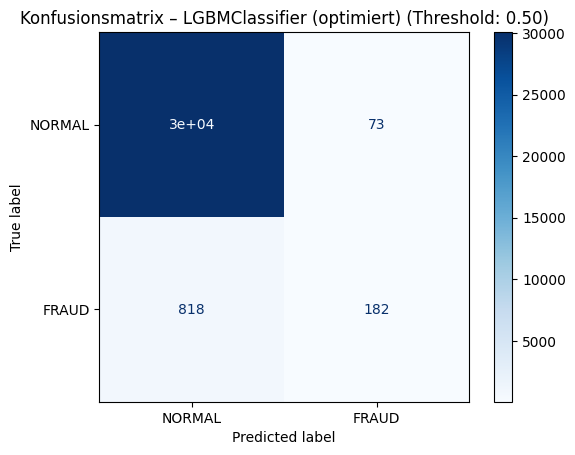

2025-06-09 06:44:18,507 - INFO - 📈 ROC-AUC: 0.8353


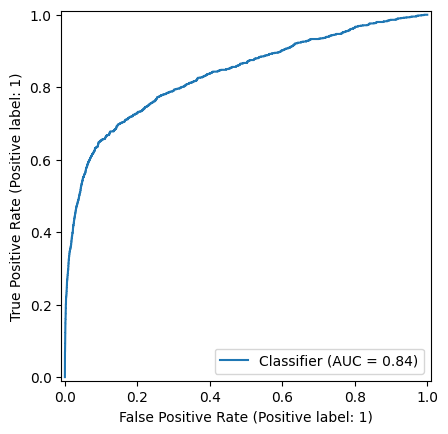

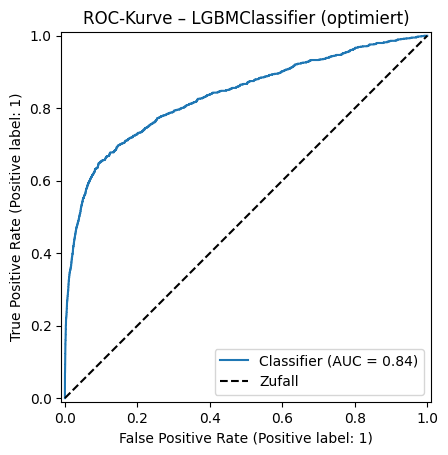

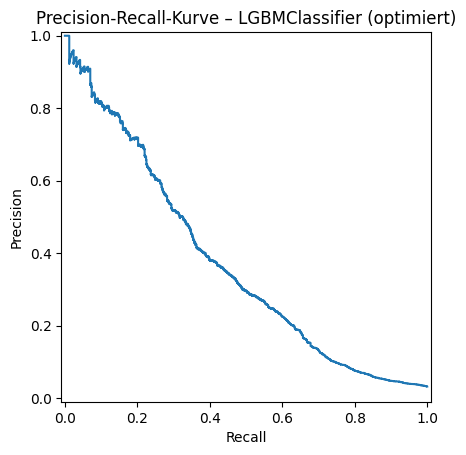


🎯 Wert der Zielfunktion: -5942.68


📊 Zusammenfassung aller Modelle:
                        Model  \
0      RandomForestClassifier   
1  GradientBoostingClassifier   
2          CatBoostClassifier   
3              LGBMClassifier   

                                         Best_Params  CV_Custom_Score  
0  {'n_estimators': 500, 'max_depth': 30, 'min_sa...       -6149.2925  
1  {'n_estimators': 300, 'learning_rate': 0.05, '...       -6109.4150  
2  {'iterations': 300, 'learning_rate': 0.08, 'de...       -6042.6575  
3  {'n_estimators': 300, 'learning_rate': 0.07, '...       -6142.8200  


In [9]:
# Speicher für alle Ergebnisse
results = []

# Master-Loop
for config in model_configs:
    print(f"\n\n==========================")
    print(f"🔍 Tune: {config['name']}")

    best_params, best_score = randomized_search_with_custom_score(
        model_class=config['model_class'],
        param_grid=config['param_grid'],
        preprocessor=preprocessor,
        X=X_train,
        y=y_train,
        damage_series=damage_train,
        n_iter=50,                          # jetzt mit 50 statt 10 Iterationen
        cv_splits=4,
        model_fixed_params=config['fixed_params']
    )
    
    # Merge fixed + best params
    full_params = {**best_params, **config['fixed_params']}

    # Train final model
    try:
        final_pipeline = Pipeline([
            ('preprocessor', preprocessor),
            ('classifier', config['model_class'](**full_params, random_state=42))
        ])
    except TypeError:
        # Falls random_state nicht unterstützt wird
        final_pipeline = Pipeline([
            ('preprocessor', preprocessor),
            ('classifier', config['model_class'](**full_params))
        ])

    final_pipeline.fit(X_train, y_train)

    # Evaluate on testset
    evaluate_model_with_curves(
        model=final_pipeline.named_steps['classifier'],
        model_name=config['name'] + " (optimiert)",
        preprocessor=preprocessor,
        X_train=X_train,
        X_test=X_test,
        y_train=y_train,
        y_test=y_test,
        damage_test=damage_test,
        threshold=0.5
    )

    # Ergebnis speichern
    results.append({
        'Model': config['name'],
        'Best_Params': full_params,
        'CV_Custom_Score': best_score
    })

# Zusammenfassung als DataFrame:
results_df = pd.DataFrame(results)
print("\n\n📊 Zusammenfassung aller Modelle:")
print(results_df)


# 5. Runde Threshold-Optimierung


🚀 Threshold-Optimierung für: RandomForestClassifier


2025-06-09 07:54:17,651 - INFO - 🔍 Starte Evaluation für Modell: RandomForestClassifier (Threshold-optimiert)


🎯 Optimaler Threshold: 0.38 mit Custom Score: -5874.82

📋 Klassifikationsbericht:
              precision    recall  f1-score   support

      NORMAL       0.98      1.00      0.99     30139
       FRAUD       0.62      0.24      0.34      1000

    accuracy                           0.97     31139
   macro avg       0.80      0.62      0.66     31139
weighted avg       0.96      0.97      0.96     31139


🔲 Konfusionsmatrix:
[[29994   145]
 [  764   236]]


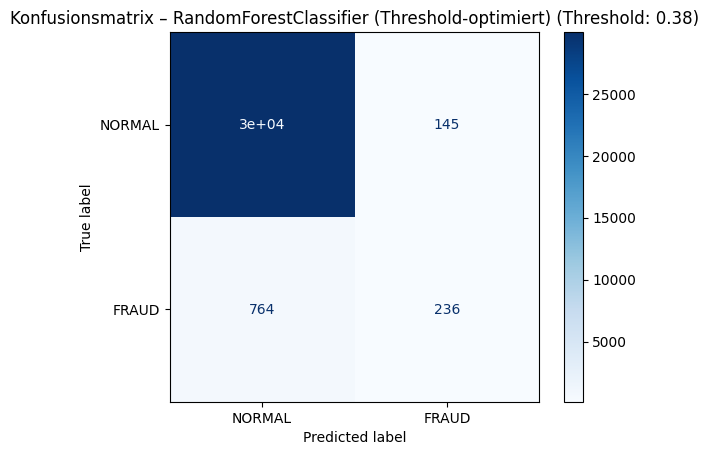

2025-06-09 07:55:26,224 - INFO - 📈 ROC-AUC: 0.8188


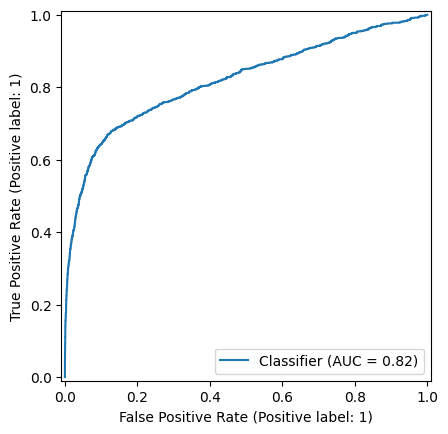

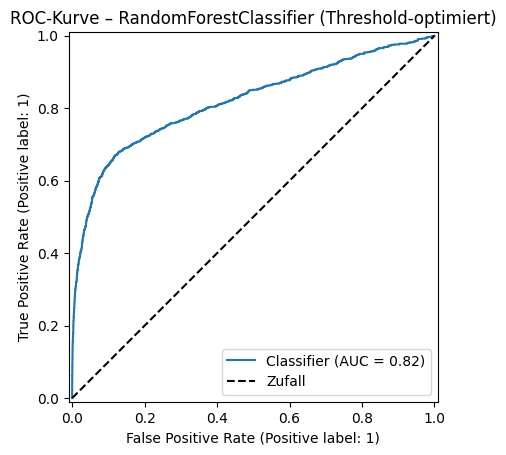

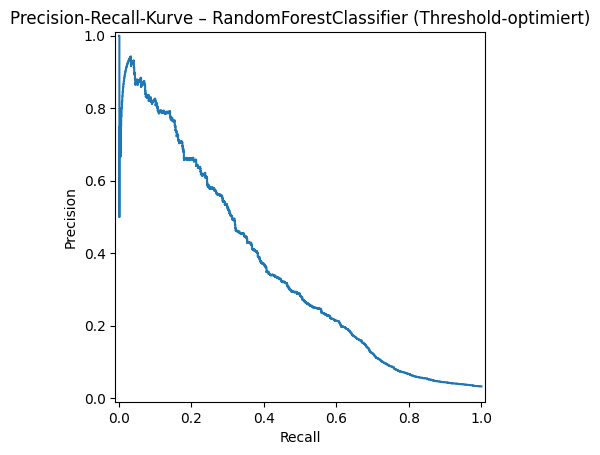


🎯 Wert der Zielfunktion: -5874.82

🚀 Threshold-Optimierung für: GradientBoostingClassifier


2025-06-09 07:59:05,504 - INFO - 🔍 Starte Evaluation für Modell: GradientBoostingClassifier (Threshold-optimiert)


🎯 Optimaler Threshold: 0.36 mit Custom Score: -5766.16

📋 Klassifikationsbericht:
              precision    recall  f1-score   support

      NORMAL       0.98      0.99      0.99     30139
       FRAUD       0.61      0.26      0.36      1000

    accuracy                           0.97     31139
   macro avg       0.79      0.63      0.67     31139
weighted avg       0.96      0.97      0.97     31139


🔲 Konfusionsmatrix:
[[29974   165]
 [  742   258]]


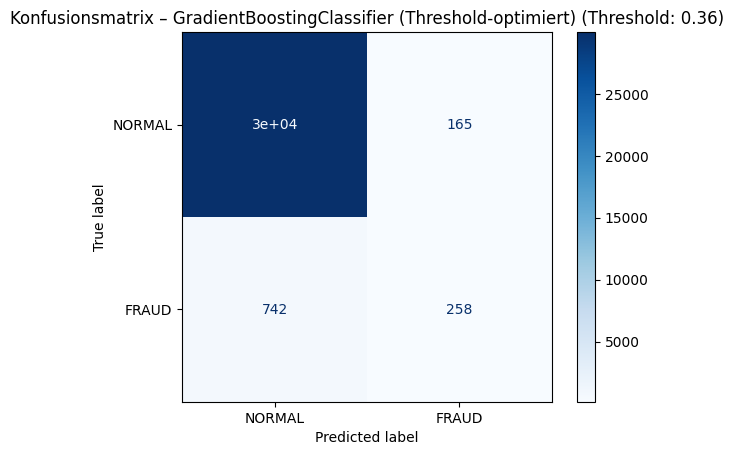

2025-06-09 08:02:07,802 - INFO - 📈 ROC-AUC: 0.8409


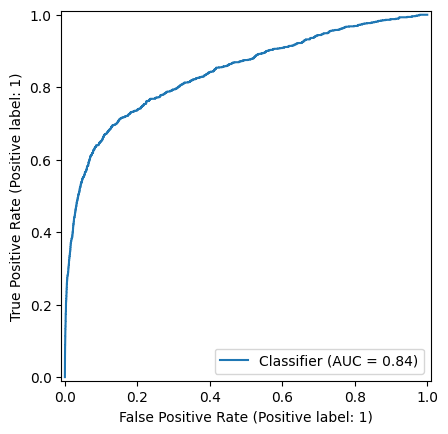

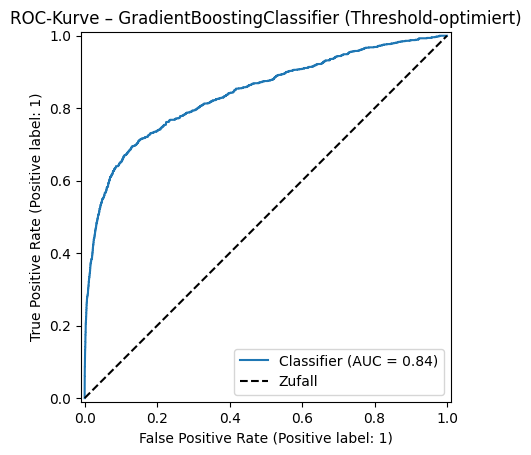

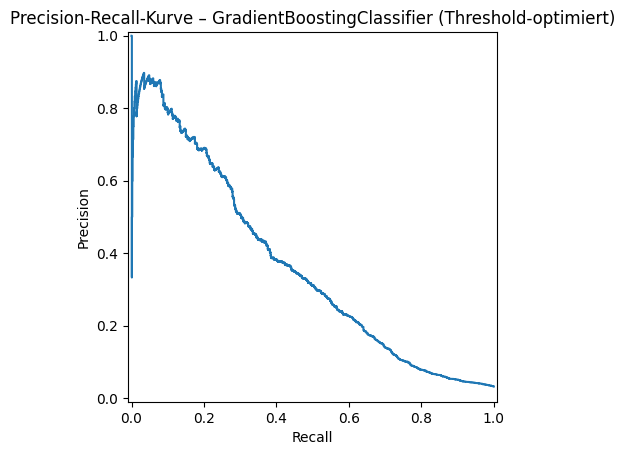


🎯 Wert der Zielfunktion: -5766.16

🚀 Threshold-Optimierung für: CatBoostClassifier


2025-06-09 08:02:50,501 - INFO - 🔍 Starte Evaluation für Modell: CatBoostClassifier (Threshold-optimiert)


🎯 Optimaler Threshold: 0.39 mit Custom Score: -5727.33

📋 Klassifikationsbericht:
              precision    recall  f1-score   support

      NORMAL       0.98      1.00      0.99     30139
       FRAUD       0.64      0.24      0.35      1000

    accuracy                           0.97     31139
   macro avg       0.81      0.62      0.67     31139
weighted avg       0.96      0.97      0.96     31139


🔲 Konfusionsmatrix:
[[30003   136]
 [  759   241]]


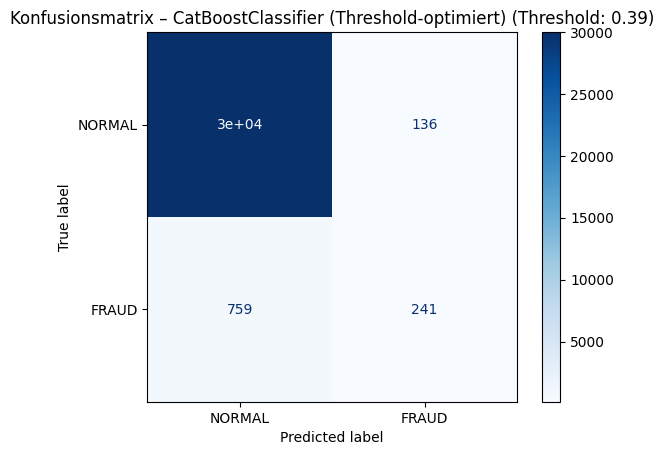

2025-06-09 08:03:06,854 - INFO - 📈 ROC-AUC: 0.8395


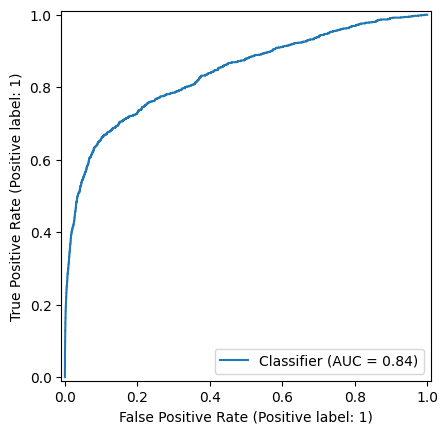

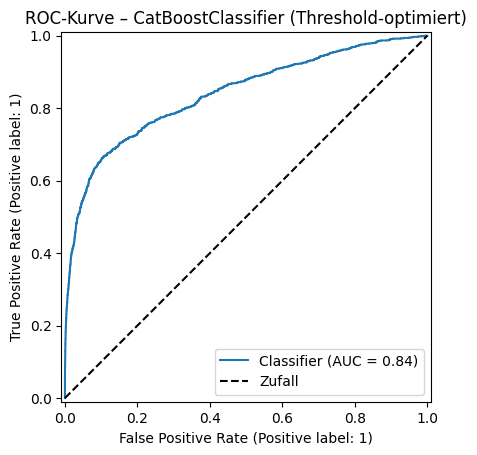

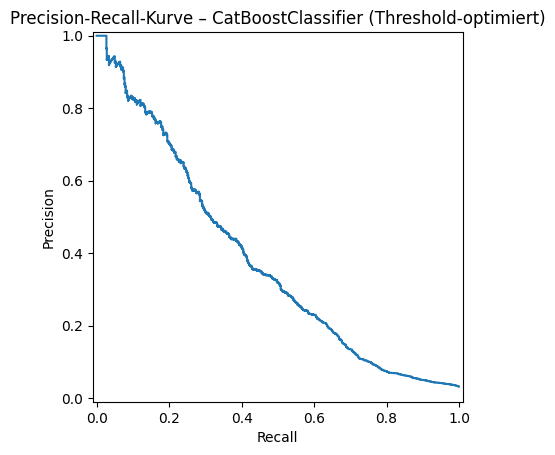


🎯 Wert der Zielfunktion: -5727.33

🚀 Threshold-Optimierung für: LGBMClassifier
[LightGBM] [Info] Number of positive: 4000, number of negative: 120553
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.018550 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2203
[LightGBM] [Info] Number of data points in the train set: 124553, number of used features: 38
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.032115 -> initscore=-3.405795
[LightGBM] [Info] Start training from score -3.405795
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positi

2025-06-09 08:03:18,879 - INFO - 🔍 Starte Evaluation für Modell: LGBMClassifier (Threshold-optimiert)


🎯 Optimaler Threshold: 0.43 mit Custom Score: -5643.49
[LightGBM] [Info] Number of positive: 4000, number of negative: 120553
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.026549 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2203
[LightGBM] [Info] Number of data points in the train set: 124553, number of used features: 38
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.032115 -> initscore=-3.405795
[LightGBM] [Info] Start training from score -3.405795
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


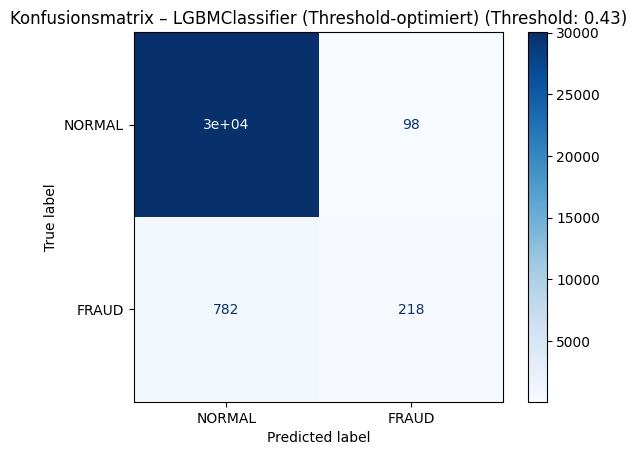

2025-06-09 08:03:29,407 - INFO - 📈 ROC-AUC: 0.8353


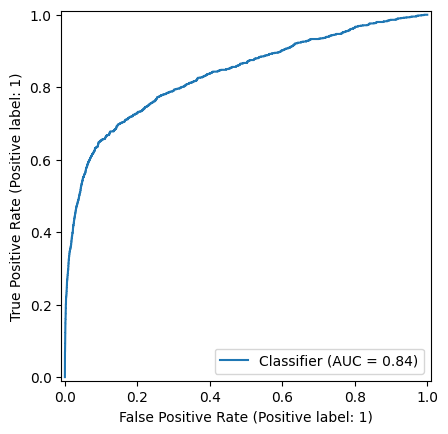

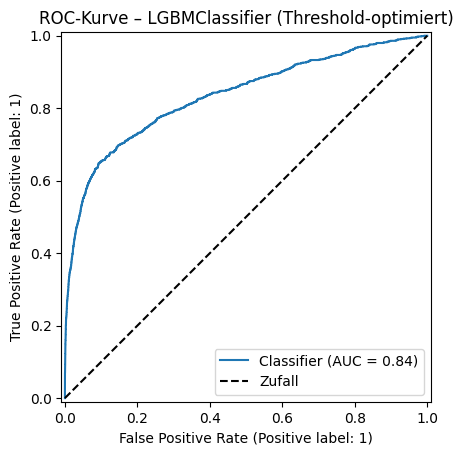

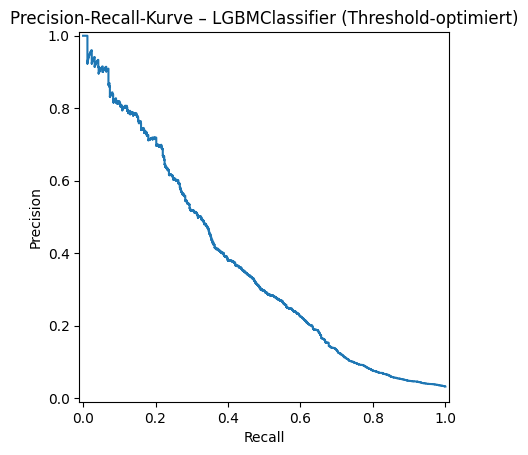


🎯 Wert der Zielfunktion: -5643.49

📊 Finales Ergebnis mit Threshold-Optimierung:
                        Model  \
0      RandomForestClassifier   
1  GradientBoostingClassifier   
2          CatBoostClassifier   
3              LGBMClassifier   

                                         Best_Params  CV_Custom_Score  \
0  {'n_estimators': 500, 'max_depth': 30, 'min_sa...       -6149.2925   
1  {'n_estimators': 300, 'learning_rate': 0.05, '...       -6109.4150   
2  {'iterations': 300, 'learning_rate': 0.08, 'de...       -6042.6575   
3  {'n_estimators': 300, 'learning_rate': 0.07, '...       -6142.8200   

   Best_Threshold  Test_Custom_Score  
0            0.38           -5874.82  
1            0.36           -5766.16  
2            0.39           -5727.33  
3            0.43           -5643.49  


In [10]:
### 1. Mapping Modellnamen zu Klassen:

model_name_to_class = {
    'RandomForestClassifier': RandomForestClassifier,
    'GradientBoostingClassifier': GradientBoostingClassifier,
    'CatBoostClassifier': CatBoostClassifier,
    'LGBMClassifier': LGBMClassifier
}


### 2. Threshold-Optimierungsfunktion:

def find_best_threshold(model, preprocessor, X_test, y_test, damage_test, thresholds=np.arange(0.01, 1.0, 0.01)):
    # Pipeline aufbauen
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    pipeline.fit(X_train, y_train)

    if not hasattr(model, "predict_proba"):
        print("⚠️ Dieses Modell unterstützt kein predict_proba.")
        return 0.5, None

    y_scores = pipeline.predict_proba(X_test)[:, 1]

    best_threshold = 0.5
    best_score = -np.inf

    for thresh in thresholds:
        y_pred = (y_scores >= thresh).astype(int)
        score = custom_objective_score(
            y_test.reset_index(drop=True),
            y_pred,
            damage_test.reset_index(drop=True)
        )
        if score > best_score:
            best_score = score
            best_threshold = thresh

    print(f"🎯 Optimaler Threshold: {best_threshold:.2f} mit Custom Score: {best_score:.2f}")
    return best_threshold, best_score


### 3. Evaluationsloop über alle Modelle:

threshold_results = []

for idx, row in results_df.iterrows():
    model_name = row['Model']
    best_params = row['Best_Params']
    model_class = model_name_to_class[model_name]

    print(f"\n🚀 Threshold-Optimierung für: {model_name}")
    
    # Modell initialisieren
    try:
        model = model_class(**best_params, random_state=42)
    except TypeError:
        # falls random_state nicht akzeptiert wird
        model = model_class(**best_params)

    # Threshold suchen
    best_thresh, best_custom_score = find_best_threshold(
        model=model,
        preprocessor=preprocessor,
        X_test=X_test,
        y_test=y_test,
        damage_test=damage_test
    )

    # Evaluationsfunktion mit dem optimalen Threshold:
    evaluate_model_with_curves(
        model=model,
        model_name=model_name + " (Threshold-optimiert)",
        preprocessor=preprocessor,
        X_train=X_train,
        X_test=X_test,
        y_train=y_train,
        y_test=y_test,
        damage_test=damage_test,
        threshold=best_thresh
    )

    # Ergebnisse speichern
    threshold_results.append({
        'Model': model_name,
        'Best_Threshold': best_thresh,
        'Test_Custom_Score': best_custom_score
    })


### 4. Zusammenfassung:

threshold_df = pd.DataFrame(threshold_results)
final_results_df = pd.merge(results_df, threshold_df, on='Model')

print("\n📊 Finales Ergebnis mit Threshold-Optimierung:")
print(final_results_df)
